# 04 - Modelling

## Data sources
- **ML-HydPARK** (Zenodo, v0.0.5): cleaned experimental thermodynamic data for metal hydrides (~770 entries)
- **ElementalH_Ef**: experimental elemental hydride formation energies, used for compositional feature engineering
- **ElementalH_Ef_MP**: Materials Project DFT calculations - not used (more missing values, DFT approximations)

## Target Variables
- `Temperature_oC`
- `Hydrogen_Weight_Percent`

## Goals
- Investigate baseline models for each dataset
- Evaluation and fine tuning of chosen models
- SHAP analysis for model interpretability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
import shap
import chemparse
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading dataset A
X_A_train = pd.read_csv('../data/processed/splits/X_A_train.csv')
X_A_val = pd.read_csv('../data/processed/splits/X_A_val.csv')
X_A_test = pd.read_csv('../data/processed/splits/X_A_test.csv')
y_A_train = pd.read_csv('../data/processed/splits/y_A_train.csv').squeeze()
y_A_val = pd.read_csv('../data/processed/splits/y_A_val.csv').squeeze()
y_A_test = pd.read_csv('../data/processed/splits/y_A_test.csv').squeeze()

# Loading dataset B
X_B_train = pd.read_csv('../data/processed/splits/X_B_train.csv')
X_B_val = pd.read_csv('../data/processed/splits/X_B_val.csv')
X_B_test = pd.read_csv('../data/processed/splits/X_B_test.csv')
y_B_train = pd.read_csv('../data/processed/splits/y_B_train.csv').squeeze()
y_B_val = pd.read_csv('../data/processed/splits/y_B_val.csv').squeeze()
y_B_test = pd.read_csv('../data/processed/splits/y_B_test.csv').squeeze()

print(X_A_train.shape, X_A_val.shape, X_A_test.shape)
print(X_B_train.shape, X_B_val.shape, X_B_test.shape)


(518, 11) (111, 11) (112, 11)
(266, 10) (57, 10) (58, 10)


## Dataset A

Target variable: `Hydrogen_Weight_Percent`

### Linear Regression: baseline model

In [3]:
# Model instantiation, training and validation
lr_A = LinearRegression()
lr_A.fit(X_A_train, y_A_train)
y_A_val_pred_lr = lr_A.predict(X_A_val)


# Evaluation
print('R²:', r2_score(y_A_val, y_A_val_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_A_val, y_A_val_pred_lr)))
print('MAE:', mean_absolute_error(y_A_val, y_A_val_pred_lr))

R²: 0.29595540128489295
RMSE: 0.5387057686587513
MAE: 0.33927526428214627


### Random Forest: baseline model

In [4]:
# Model instantiation, training and validation
rf_A = RandomForestRegressor(random_state=42)
rf_A.fit(X_A_train, y_A_train)
y_A_val_pred_rf = rf_A.predict(X_A_val)

# Evaluation
print('R²:', r2_score(y_A_val, y_A_val_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_A_val, y_A_val_pred_rf)))
print('MAE:', mean_absolute_error(y_A_val, y_A_val_pred_rf))

R²: 0.5035110774079903
RMSE: 0.452383047844764
MAE: 0.3024317590121182


### XGBoost Regressor: baseline model

In [5]:
# Model instantiation, training and validation
xgb_A = XGBRegressor()
xgb_A.fit(X_A_train, y_A_train)
y_A_val_pred_xgb = xgb_A.predict(X_A_val)


# Evaluation
print('R²:', r2_score(y_A_val, y_A_val_pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_A_val, y_A_val_pred_xgb)))
print('MAE:', mean_absolute_error(y_A_val, y_A_val_pred_xgb))

R²: 0.4207742780016551
RMSE: 0.48862474909310166
MAE: 0.3333662903103805


## Baseline Models Comparison

Random Forest is the best performing model compared to XGBoost and Linear Regression:

| Model | R² | RMSE | MAE |
|---|---|---|---|
| Linear Regression | 0.296 | 0.539 | 0.339 |
| Random Forest | 0.501 | 0.453 | 0.302 |
| XGBoost | 0.421 | 0.489 | 0.333 |

Random Forest is the best model with an R²=0.501, which means that the vanilla model explains approximately half of the variance in `Hydrogen_Weight_Percent`.

## Next Steps

Feature engineering: adding the `ElementalH_Ef` to the features could help the model better understand and distinguish between hydrogen storage materials with similar enthalpy of formation but different elemental composition.

### Feature Engineering

Exploring the `ElementalH_Ef` and `ElementalH_Ef_MP` datasets to understand how to leverage them as features.

In [6]:
# Loading the ElementalH_Ef dataset
df_H_Ef = pd.read_csv('../data/raw/ElementalH_Ef.csv')
df_H_Ef.head()

,No,Species,Ef
0,1.0,NaN,NaN
1,2.0,NaN,NaN
2,3.0,Li,-0.41
3,4.0,Be,-0.04
4,5.0,B,-0.08


In [7]:
# Checking shape and missing values in df_H_Ef
print(df_H_Ef.shape)
print(df_H_Ef.isna().sum())

(94, 3)
No         1
Species    8
Ef         8
dtype: int64


In [8]:
# Loading the ElementalH_Ef_MP dataset
df_H_Ef_MP = pd.read_csv('../data/raw/ElementalH_Ef_MP.csv')
df_H_Ef_MP.head()

,Unnamed: 0,No,Species,Ef
0,0,1.0,NaN,NaN
1,1,2.0,NaN,NaN
2,2,3.0,Li,-0.482520
3,3,4.0,Be,-0.149158
4,4,5.0,B,-0.174701


In [9]:
# Checking shape and missing values in df_H_Ef_MP
print(df_H_Ef_MP.shape)
print(df_H_Ef_MP.isna().sum())

(94, 4)
Unnamed: 0     0
No             1
Species        8
Ef            15
dtype: int64


`ElementalH_Ef` contains experimental formation energies, whereas `ElementalH_Ef_MP` comes from Materials Project DFT calculations.

`ElementalH_Ef` is preferred for two reasons: it contains fewer missing values (8 vs 15), and it is methodologically more consistent with ML-HydPARK, which is also experimentally derived. Using experimental features alongside experimental target data reduces the risk of systematic bias introduced by DFT approximations.

In [10]:
# Dropping missing values from df_H_Ef
df_H_Ef = df_H_Ef.dropna()

# Creating a dictionary that has elements as keys and their H as value
ef_dict = dict(zip(df_H_Ef['Species'], df_H_Ef['Ef']))
ef_dict


{'Li': -0.41,
 'Be': -0.04,
 'B': -0.08,
 'C': -0.14,
 'N': -0.37,
 'O': -1.18,
 'F': -1.62,
 'Na': -0.25,
 'Mg': -0.18,
 'Al': -0.01,
 'Si': 0.03,
 'P': 0.63,
 'S': -0.24,
 'Cl': -0.67,
 'Ar': 0.0,
 'K': -0.2,
 'Ca': -0.57,
 'Sc': -0.67,
 'Ti': -0.49,
 'V': -0.2,
 'Cr': 0.02,
 'Mn': 0.24,
 'Fe': 0.0,
 'Co': 0.16,
 'Ni': -0.05,
 'Cu': 0.13,
 'Zn': 0.41,
 'Ga': 0.36,
 'Ge': 0.12,
 'As': 0.68,
 'Se': 0.79,
 'Br': -0.39,
 'Kr': 0.0,
 'Rb': -0.16,
 'Sr': -0.54,
 'Y': -0.7,
 'Zr': -0.56,
 'Nb': -0.23,
 'Mo': 0.4,
 'Tc': 0.47,
 'Ru': 0.45,
 'Rh': 0.04,
 'Pd': -0.07,
 'Ag': 0.58,
 'Cd': 0.46,
 'In': 0.4,
 'Sn': 0.19,
 'Sb': 0.59,
 'Te': 0.74,
 'I': -0.07,
 'Xe': 0.0,
 'Cs': -0.16,
 'Ba': -0.49,
 'La': -0.63,
 'Ce': -0.59,
 'Pr': -0.61,
 'Nd': -0.63,
 'Pm': -0.52,
 'Sm': -0.65,
 'Eu': -0.64,
 'Gd': -0.68,
 'Tb': -0.47,
 'Dy': -0.69,
 'Ho': -0.69,
 'Er': -0.69,
 'Tm': -0.69,
 'Yb': 0.62,
 'Lu': -0.68,
 'Hf': -0.49,
 'Ta': -0.15,
 'W': 0.62,
 'Re': 0.73,
 'Os': 0.73,
 'Ir': 0.52,
 'Pt': 0.54,
 '

The `Ef` values in `ef_dict` are consistent with known hydride chemistry: elements such as La, Ce, Zr and Ti have negative Ef (stable hydride formers), while Mn, Fe and Cr are near zero or positive (unstable hydrides). This confirms the dictionary can be used as a meaningful feature for the model.

In [11]:
# Creating the function to calculate Ef_weighted
def compute_ef_weighted(formula, ef_dict):
    elements = chemparse.parse_formula(formula)
    total = sum(elements.values())
    weighted_ef = 0
    for element, count in elements.items():
        if element in ef_dict:
            weighted_ef += (count / total) * ef_dict[element]
    return weighted_ef

In [12]:
# Testing the function on LaNi5
compute_ef_weighted('LaNi5', ef_dict)

-0.14666666666666667

### Verifying the output of compute_ef_weighted

For `LaNi5` (total atoms = 6):

- Ef(La) = -0.63 → contribution: (1/6) × (-0.63) = -0.105
- Ef(Ni) = -0.05 → contribution: (5/6) × (-0.05) = -0.042

Ef_weighted = -0.105 + (-0.042) = -0.147 ✓

In [13]:
# Reload original cleaned data to access Composition_Formula
df_raw = pd.read_csv('../data/processed/ML-HYDPARK_eda_cleaned.csv')

# Recreate Dataset A filtering. Same as notebook 03
df_A_orig = df_raw.dropna(subset=['Hydrogen_Weight_Percent']).copy().reset_index(drop=True)

In [14]:
# Compute weighted average Ef for each compound
ef_values = []
for formula in df_A_orig['Composition_Formula']:
    ef = compute_ef_weighted(formula, ef_dict)
    ef_values.append(ef)

df_A_orig['Ef_weighted'] = ef_values

df_A_orig[['Composition_Formula', 'Ef_weighted']].head()


,Composition_Formula,Ef_weighted
0,Th2Al,-0.323333
1,Ti2Cu,-0.283333
2,Zr2Cu,-0.330000
3,Zr2Ni,-0.390000
4,Mg2Ni,-0.136667


In [15]:
# Recreate the same train/val/test split indices as notebook 03
# Assumption: split indices must match those used in notebook 03 (random_state=42, test_size=0.30/0.50)
idx = df_A_orig.index
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

# Add Ef_weighted to each split
X_A_train['Ef_weighted'] = df_A_orig.loc[idx_train, 'Ef_weighted'].values
X_A_val['Ef_weighted'] = df_A_orig.loc[idx_val, 'Ef_weighted'].values
X_A_test['Ef_weighted'] = df_A_orig.loc[idx_test, 'Ef_weighted'].values

print(X_A_train.shape)

(518, 12)


In [16]:
# Checking the shape of train/val/test splits
print(X_A_train.shape, X_A_val.shape, X_A_test.shape)

(518, 12) (111, 12) (112, 12)


## Baseline models with added Ef_weighted feature

### Linear Regression

In [17]:
# Model instantiation, training and validation
lr_A = LinearRegression()
lr_A.fit(X_A_train, y_A_train)
y_A_val_pred_lr = lr_A.predict(X_A_val)


# Evaluation
print('R²:', r2_score(y_A_val, y_A_val_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_A_val, y_A_val_pred_lr)))
print('MAE:', mean_absolute_error(y_A_val, y_A_val_pred_lr))

R²: 0.4125088383603662
RMSE: 0.49209869046582083
MAE: 0.32166775113961155


### Random Forest

In [18]:
# Model instantiation, training and validation
rf_A = RandomForestRegressor(random_state=42)
rf_A.fit(X_A_train, y_A_train)
y_A_val_pred_rf = rf_A.predict(X_A_val)

# Evaluation
print('R²:', r2_score(y_A_val, y_A_val_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_A_val, y_A_val_pred_rf)))
print('MAE:', mean_absolute_error(y_A_val, y_A_val_pred_rf))

R²: 0.6181552882605794
RMSE: 0.39672989817756743
MAE: 0.2619541338503753


### XGBoost

In [19]:
# Model instantiation, training and validation
xgb_A = XGBRegressor()
xgb_A.fit(X_A_train, y_A_train)
y_A_val_pred_xgb = xgb_A.predict(X_A_val)


# Evaluation
print('R²:', r2_score(y_A_val, y_A_val_pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_A_val, y_A_val_pred_xgb)))
print('MAE:', mean_absolute_error(y_A_val, y_A_val_pred_xgb))

R²: 0.5966240849659128
RMSE: 0.4077617856609055
MAE: 0.2809318794042477


### Comparison between models before and after feature engineering

All three models show a noticeably higher R² value, with Random Forest still being the best model among the three.

| Model | R² (baseline) | R² (+ Ef_weighted) |
|---|---|---|
| Linear Regression | 0.296 | 0.413 |
| Random Forest | 0.501 | **0.618** |
| XGBoost | 0.421 | 0.597 |

**Next step**: fine tuning of Random Forest model.

### Random Forest: hyperparameter tuning

In [20]:
# Hyperparameter grid for RandomizedSearchCV
# max_depth capped at 30 to prevent overfitting
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_A_train, y_A_train)

print('Best parameters:', rf_random.best_params_)
print('Best R²:', rf_random.best_score_)


Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best R²: 0.5999698895223715


In [ ]:
# Evaluation of the tuned model on the validation set
rf_tuned = rf_random.best_estimator_
y_A_val_pred_rf_tuned = rf_tuned.predict(X_A_val)

print('R²:', r2_score(y_A_val, y_A_val_pred_rf_tuned))
print('RMSE:', np.sqrt(mean_squared_error(y_A_val, y_A_val_pred_rf_tuned)))
print('MAE:', mean_absolute_error(y_A_val, y_A_val_pred_rf_tuned))


R²: 0.557948670934522
RMSE: 0.4268623893199297
MAE: 0.2763748542525025


### Dataset A: Random Forest Optimisation

Hyperparameter tuning via `RandomizedSearchCV` (n_iter=100, cv=5) did not improve over the vanilla model: the best tuned R²=0.558 vs vanilla R²=0.618 on the validation set.

With only 518 training samples, hyperparameter tuning via cross-validation did not generalise well to the validation set, likely due to high variance with small data. The vanilla Random Forest is retained as the final model for Dataset A.

In [22]:
# Final evaluation on test set - Dataset A (Random Forest vanilla + Ef_weighted)
y_A_test_pred_rf = rf_A.predict(X_A_test)

print('=== Dataset A - Test Set Evaluation (Random Forest) ===')
print('R²:', r2_score(y_A_test, y_A_test_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_A_test, y_A_test_pred_rf)))
print('MAE:', mean_absolute_error(y_A_test, y_A_test_pred_rf))

=== Dataset A - Test Set Evaluation (Random Forest) ===
R²: 0.7650621717826354
RMSE: 0.3188227591614726
MAE: 0.21880498235024512


### Dataset A: Final Test Set Evaluation

| Split | R² | RMSE | MAE |
|---|---|---|---|
| Validation | 0.618 | 0.397 | 0.262 |
| **Test** | **0.765** | **0.319** | **0.219** |

The vanilla Random Forest (+ Ef_weighted) achieves R²=0.765 on the held-out test set, showing good generalisation despite the small dataset size (518 training samples). The gap between validation and test performance suggests the validation set may have been slightly harder to predict, not overfitting.


## SHAP Analysis: Dataset A

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to individual predictions, showing not just which features matter globally but how they push predictions higher or lower for each compound.

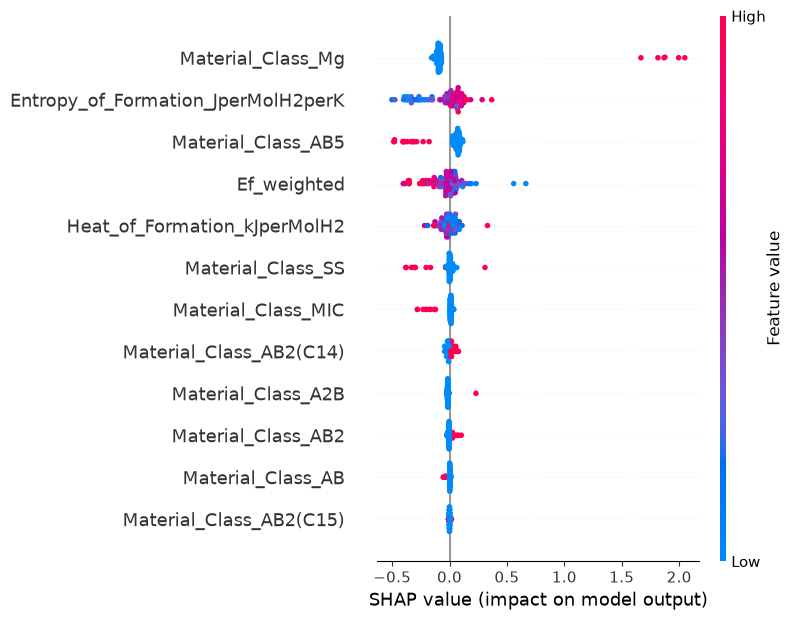

In [23]:
explainer = shap.TreeExplainer(rf_A)
shap_values = explainer.shap_values(X_A_test)

# Summary plot: feature importance + direction of effect
shap.summary_plot(shap_values, X_A_test, show=False)
plt.savefig('../results/shap_summary_A.png', dpi=150, bbox_inches='tight')
plt.show()

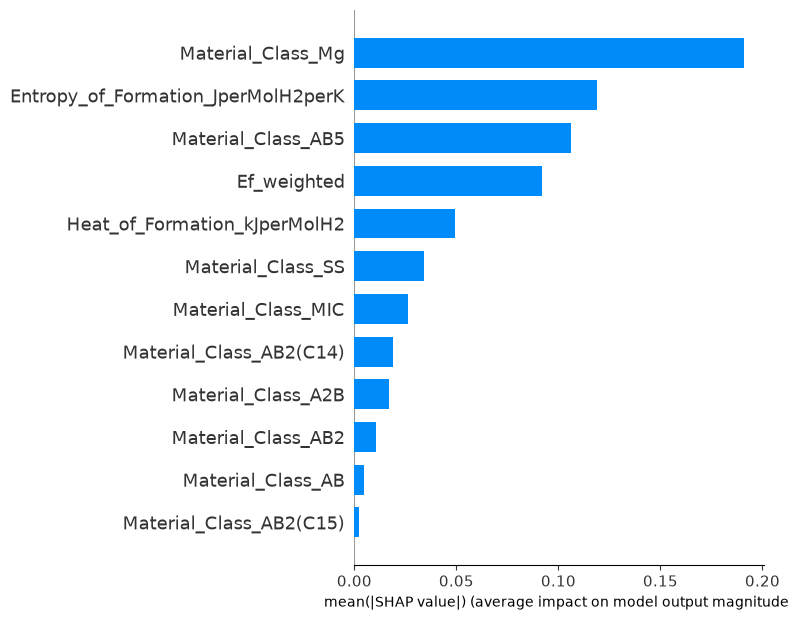

In [24]:
# Bar plot: mean absolute SHAP values (global importance ranking)
fig, ax = plt.subplots(figsize=(9, 5))
shap.summary_plot(shap_values, X_A_test, plot_type='bar', show=False)
plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)', fontsize=10)
plt.tight_layout()
plt.savefig('../results/shap_bar_A.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP Summary Plot: Interpretation

The summary plot shows both feature importance and direction of effect. Each point is one test sample. The x-axis shows how much a feature shifts the prediction (right = higher wt%, left = lower). Color encodes the feature value (red = high, blue = low).

**Material_Class_Mg**: the most impactful feature. High values (red, i.e. the compound is Mg-based) push predictions strongly to the right (+2 wt%). Consistent with Mg-based hydrides having the highest wt% in the dataset.

**Entropy_of_Formation_JperMolH2perK**: mixed colors on both sides, indicating a complex non-linear effect that depends on interactions with other features. No simple directional relationship with wt%. 

**Material_Class_AB5**: high values (red, i.e. AB5 compound) push predictions to the left, lowering predicted wt%. Consistent with AB5 compounds like LaNi5 having low wt% (~1.8%).

**Ef_weighted**: high values (less negative, i.e. elements less prone to forming stable hydrides individually) slightly increase predicted wt%. The effect is moderate and partially mediated by material class.

**Heat_of_Formation_kJperMolH2**: similar to entropy, the effect is mixed and non-linear.

**Takeaway**: structural class (especially Mg-based vs AB5) dominates predictions. Thermodynamic features (Ef_weighted, entropy, heat of formation) add chemical nuance that the class labels alone cannot capture.

**Note on Entropy_of_Formation**: ranks second in global importance but shows small individual SHAP values in the beeswarm plot. This is consistent with the near-constancy of desorption entropy across metal hydrides (typically between 100 and 130 J/mol H₂/K): the dominant contribution comes from H₂ gas entropy, not the metal structure, leaving little variance to exploit at the individual sample level. Its global importance likely reflects interaction effects with other features rather than a direct relationship with wt%.

## Dataset B

Target variable: `Temperature_oC`

### Linear Regression: baseline model

In [25]:
# Model instantiation, training and validation
lr_B = LinearRegression()
lr_B.fit(X_B_train, y_B_train)
y_B_val_pred_lr = lr_B.predict(X_B_val)


# Evaluation
print('R²:', r2_score(y_B_val, y_B_val_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_B_val, y_B_val_pred_lr)))
print('MAE:', mean_absolute_error(y_B_val, y_B_val_pred_lr))

R²: 0.8845630724597744
RMSE: 50.55602130280766
MAE: 37.07812226046401


### Random Forest: baseline model

In [26]:
# Model instantiation, training and validation
rf_B = RandomForestRegressor(random_state=42)
rf_B.fit(X_B_train, y_B_train)
y_B_val_pred_rf = rf_B.predict(X_B_val)

# Evaluation
print('R²:', r2_score(y_B_val, y_B_val_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_B_val, y_B_val_pred_rf)))
print('MAE:', mean_absolute_error(y_B_val, y_B_val_pred_rf))

R²: 0.8444255622607064
RMSE: 58.69074585590822
MAE: 37.07228070175439


### XGBoost Regressor: baseline model

In [27]:
# Model instantiation, training and validation
xgb_B = XGBRegressor()
xgb_B.fit(X_B_train, y_B_train)
y_B_val_pred_xgb = xgb_B.predict(X_B_val)


# Evaluation
print('R²:', r2_score(y_B_val, y_B_val_pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_B_val, y_B_val_pred_xgb)))
print('MAE:', mean_absolute_error(y_B_val, y_B_val_pred_xgb))

R²: 0.8424350459662846
RMSE: 59.06501548744676
MAE: 37.66518636544546


### Baseline Models Comparison

| Model | R² | RMSE (°C) | MAE (°C) |
|---|---|---|---|
| **Linear Regression** | **0.885** | **50.6** | **37.1** |
| Random Forest | 0.844 | 58.7 | 37.1 |
| XGBoost | 0.842 | 59.1 | 37.7 |

Linear Regression outperforms both ensemble models, suggesting a predominantly linear relationship between the features and desorption temperature. However, despite the high R², a RMSE of ~50°C is too large for practical screening purposes. For near-RT hydrogen storage applications, a prediction error of 50°C is the difference between a material that works and one that does not: it would make it impossible to reliably identify candidates with desorption temperatures below or near room temperature.

**Next step**: feature engineering with Ef_weighted, which is physically motivated by the Van't Hoff relationship between hydride stability and desorption temperature.

In [32]:
# Reload original cleaned data to access Composition_Formula
df_raw = pd.read_csv('../data/processed/ML-HYDPARK_eda_cleaned.csv')

# Recreate Dataset B filtering. Same as notebook 03
df_B_orig = df_raw.dropna(subset=['Temperature_oC']).copy().reset_index(drop=True)
df_B_orig = df_B_orig.dropna(subset=['Hydrogen_Weight_Percent', 'Pressure_Atmospheres_Absolute']).reset_index(drop=True)

In [33]:
# Compute weighted average Ef for each compound
ef_values = []
for formula in df_B_orig['Composition_Formula']:
    ef = compute_ef_weighted(formula, ef_dict)
    ef_values.append(ef)

df_B_orig['Ef_weighted'] = ef_values

df_B_orig[['Composition_Formula', 'Ef_weighted']].head()

,Composition_Formula,Ef_weighted
0,Th2Al,-0.323333
1,Ti2Cu,-0.283333
2,Zr2Cu,-0.330000
3,Zr2Ni,-0.390000
4,Mg2Ni,-0.136667


In [35]:
# Recreate the same train/val/test split indices as notebook 03
# Assumption: split indices must match those used in notebook 03 (random_state=42, test_size=0.30/0.50)
idx = df_B_orig.index
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

# Add Ef_weighted to each split
X_B_train['Ef_weighted'] = df_B_orig.loc[idx_train, 'Ef_weighted'].values
X_B_val['Ef_weighted'] = df_B_orig.loc[idx_val, 'Ef_weighted'].values
X_B_test['Ef_weighted'] = df_B_orig.loc[idx_test, 'Ef_weighted'].values

print(X_B_train.shape)

(266, 11)


In [36]:
# Checking the shape of train/val/test splits
print(X_B_train.shape, X_B_val.shape, X_B_test.shape)

(266, 11) (57, 11) (58, 11)


## Baseline models with added Ef_weighted feature

### Linear Regression

In [37]:
# Model instantiation, training and validation
lr_B = LinearRegression()
lr_B.fit(X_B_train, y_B_train)
y_B_val_pred_lr = lr_B.predict(X_B_val)


# Evaluation
print('R²:', r2_score(y_B_val, y_B_val_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_B_val, y_B_val_pred_lr)))
print('MAE:', mean_absolute_error(y_B_val, y_B_val_pred_lr))

R²: 0.8860595929111661
RMSE: 50.22724899746636
MAE: 37.00122482638484


### Random Forest

In [ ]:
# Model instantiation, training and validation
rf_B = RandomForestRegressor(random_state=42)
rf_B.fit(X_B_train, y_B_train)
y_B_val_pred_rf = rf_B.predict(X_B_val)

# Evaluation
print('R²:', r2_score(y_B_val, y_B_val_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_B_val, y_B_val_pred_rf)))
print('MAE:', mean_absolute_error(y_B_val, y_B_val_pred_rf))

### XGBoost Regressor

In [39]:
# Model instantiation, training and validation
xgb_B = XGBRegressor()
xgb_B.fit(X_B_train, y_B_train)
y_B_val_pred_xgb = xgb_B.predict(X_B_val)


# Evaluation
print('R²:', r2_score(y_B_val, y_B_val_pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_B_val, y_B_val_pred_xgb)))
print('MAE:', mean_absolute_error(y_B_val, y_B_val_pred_xgb))

R²: 0.8362297521428637
RMSE: 60.2168469997353
MAE: 37.412930731187785


### Comparison: baseline vs Ef_weighted

| Model | R² (baseline) | R² (+Ef_weighted) | RMSE baseline (°C) | RMSE +Ef_weighted (°C) |
|---|---|---|---|---|
| **Linear Regression** | **0.885** | **0.886** | **50.6** | **50.2** |
| Random Forest | 0.844 | 0.864 | 58.7 | 54.8 |
| XGBoost | 0.842 | 0.836 | 59.1 | 60.2 |

Adding Ef_weighted brought modest improvements to Random Forest (RMSE 58.7 → 54.8°C, MAE 37.1 → 32.7°C) but had negligible effect on Linear Regression and slightly degraded XGBoost. Linear Regression remains the best model on both R² and RMSE.

However, a RMSE of ~50°C is too large for practical use. For near-RT screening, this margin of error makes it impossible to reliably distinguish materials that desorb at 20°C from those that desorb at 70°C. This is likely a dataset size problem: with only 266 training samples, the models cannot learn the fine-grained temperature dependence of hydride desorption.

**Next step**: RandomizedSearchCV on Random Forest to check whether hyperparameter tuning can meaningfully reduce the RMSE. If not, the conclusion is that Dataset B requires more data before a reliable predictive model can be built.


### Random Forest: hyperparameter tuning

In [40]:
# Hyperparameter grid for RandomizedSearchCV
# max_depth capped at 30 to prevent overfitting
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_B_train, y_B_train)

print('Best parameters:', rf_random.best_params_)
print('Best R²:', rf_random.best_score_)

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 30}
Best R²: 0.7637182033148331


In [41]:
# Evaluation of the tuned model on the validation set
rf_tuned = rf_random.best_estimator_
y_B_val_pred_rf_tuned = rf_tuned.predict(X_B_val)

print('R²:', r2_score(y_B_val, y_B_val_pred_rf_tuned))
print('RMSE:', np.sqrt(mean_squared_error(y_B_val, y_B_val_pred_rf_tuned)))
print('MAE:', mean_absolute_error(y_B_val, y_B_val_pred_rf_tuned))

R²: 0.8587689096181559
RMSE: 55.91980711042479
MAE: 34.14272493734336


### Dataset B - Random Forest Optimisation

| Model | R² | RMSE (°C) | MAE (°C) |
|---|---|---|---|
| Linear Regression (+Ef_weighted) | **0.886** | **50.2** | **37.0** |
| Random Forest vanilla (+Ef_weighted) | 0.864 | 54.8 | 32.7 |
| Random Forest tuned (+Ef_weighted) | 0.859 | 55.9 | 34.1 |

Hyperparameter tuning did not improve over the vanilla Random Forest, and neither model surpasses Linear Regression. With only 266 training samples, cross-validation cannot find hyperparameters that generalise reliably.

**Linear Regression is retained as the final model for Dataset B.** However, a RMSE of ~50°C remains too large for practical near-RT screening. This is a fundamental limitation of the dataset size, not of the modelling approach.

In [42]:
# Final evaluation on test set - Dataset B (Linear Regression + Ef_weighted)
y_B_test_pred_lr = lr_B.predict(X_B_test)

print('=== Dataset B - Test Set Evaluation (Linear Regression) ===')
print('R²:', r2_score(y_B_test, y_B_test_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_B_test, y_B_test_pred_lr)))
print('MAE:', mean_absolute_error(y_B_test, y_B_test_pred_lr))

=== Dataset B - Test Set Evaluation (Linear Regression) ===
R²: 0.7003432056593016
RMSE: 86.71611911997957
MAE: 44.91462525636597


### Dataset B: Final Test Set Evaluation

| Split | R² | RMSE (°C) | MAE (°C) |
|---|---|---|---|
| Validation | 0.886 | 50.2 | 37.0 |
| **Test** | **0.700** | **86.7** | **44.9** |

The large gap between validation and test performance indicates that the model did not generalise. The validation set appears to have been more favourable than the test set by chance, given the small dataset size (57 validation samples). This highlights the instability of evaluation metrics with few samples.

This result, combined with the consistently high RMSE across all models and the small dataset size (266 training samples), leads to a clear conclusion: **Dataset B cannot be modelled reliably with the available data.** Predicting desorption temperature with a RMSE of ~87°C on unseen data is not useful for near-RT screening, where precision within a few degrees matters.

The path forward is not better models, but more data. A larger, more diverse dataset of experimental desorption temperatures would be needed before a predictive model can be trusted for screening purposes.

## Conclusions and Next Steps

### Summary

Two independent models were developed to predict key hydrogen storage properties of metal hydrides.

**Dataset A - Hydrogen Storage Capacity (wt%)**
The best model is a vanilla Random Forest trained on thermodynamic and structural features, augmented with a compositionally-weighted elemental hydride formation energy feature (Ef_weighted). The model achieves R²=0.765 on the held-out test set, with a MAE of 0.22 wt% H₂. SHAP analysis confirmed that the model learned physically meaningful patterns: Mg-based compounds dominate positive predictions, while AB5 compounds are consistently associated with lower capacity.

**Dataset B - Desorption Temperature (°C)**
Linear Regression was the best-performing baseline (validation R²=0.886, RMSE=50°C), but test set evaluation revealed poor generalisation (R²=0.700, RMSE=87°C). This result, consistent across all models and hyperparameter tuning attempts, is attributable to insufficient training data (266 samples). A RMSE of ~87°C is not acceptable for near-RT screening purposes.

### Next Steps

- **Notebook 05**: candidate screening using the Dataset A model, identify compounds with predicted wt% above a meaningful threshold
- **Dataset B**: explore additional experimental data sources to expand the training set before attempting further modelling of desorption temperature